# LasView tour: well ABD001

This notebook shows what `pphys.LasView` can tell you about a LAS file, using `real_field_data.las`. The file is a cased-hole cement evaluation run in well ABD001 (Absheron field, Azerbaijan): a Baker Hughes Segmented Bond Tool (SBT) with gamma ray, casing collar locator, deviation, cable tension and logging speed, recorded from 5561 m to 6796 m.

Every table is a `pandas.DataFrame` and every plot a `matplotlib` figure. Plots are assigned to `fig` so that Jupyter shows each one once. The full reference is in [`doc/lasview.md`](../doc/lasview.md).

In [1]:
import tempfile
from pathlib import Path

import pandas as pd

from pphys import LasView

pd.set_option("display.max_colwidth", 70)

# Balakhany formation tops (m, measured depth)
tops = {
    "E1 Bal": 5838.0,
    "Bal V": 5944.0,
    "Bal VI": 6180.8,
    "Bal VII": 6265.8,
    "Bal VIIIA": 6441.0,
    "Bal VIIIB": 6598.0,
    "Bal VIIIC": 6633.0,
}

view = LasView("real_field_data.las", tops=tops)
view

LasView(well='ABD001', curves=17, depth=5560.92-6796.2 M)

`LasView` reads the file with `pphys.read`. Pass `cache_path=` to keep a pickle cache, or give it a log you have already loaded (`pphys.WellLog` or any `lasio.LASFile`).

## 1. File overview

`summary()` collects the well identity, the depths declared in the header and the depths actually present in the data.

In [2]:
view.summary()

well                      ABD001
field                   ABSHERON
company                    TOTAL
service company     Baker Hughes
date                 22-APR-2019
location           HEYDAR ALIYEV
country               AZERBAIJAN
LAS version                  2.0
depth curve                 DEPT
depth unit                     M
header start           5560.9236
header stop            6796.2018
header step               0.0762
data top               5560.9236
data bottom            6796.2018
median step               0.0762
samples                    16212
curves                        17
null value               -999.25
Name: ABD001, dtype: object

`header(section)` returns any header section as a table: `"well"`, `"curves"`, `"parameters"` or `"version"`. The parameter section holds the logging conditions, e.g. the mud type and density, the maximum deviation and the tool string.

In [3]:
view.header("well")

,mnemonic,unit,value,description
0,STRT,M,5560.9236,Starting Depth
1,STOP,M,6796.2018,Ending Depth
2,STEP,M,0.0762,Level Spacing
3,NULL,,-999.25,Absent Value
4,COMP,,TOTAL,Company
5,WELL,,ABD001,Well
6,FLD,,ABSHERON,Field
7,LOC,,HEYDAR ALIYEV,Location
8,PROV,,,Province
9,CTRY,,AZERBAIJAN,Country


In [4]:
view.header("parameters").head(12)

,mnemonic,unit,value,description
0,HIDE,,SEGMENTED BOND TOOL^S,Header Identifier
1,HID1,,GAMMA RAY LOG,Header Identifier
2,HID2,,CASING COLLAR LOCATOR,Header Identifier
3,HID3,,VARIABLE DENSITY LOG,Header Identifier
4,HID4,,COMPENSATED Z-DENSILOG^S,Header Identifier
5,HID5,,COMPENSATED NEUTRON LOG,Header Identifier
6,HID6,,TTRM SUB^S,N/A
7,HID7,,"*** 7"" LINER ***",N/A
8,CMT1,,FINAL PRINT,Comment 1
9,CMT2,,1:200,Comment 2


The `~Other` section carries the service company's remarks. Here it holds the cement-map calibration: the attenuation that corresponds to 0 % and 100 % bond for each casing size.

In [5]:
print(view.other)


1.  LOG OBJECTIVE IS TO EVALUATE CEMENT INTEGRITY BEHIND 10" & 13.375" CASING

2.   LOG WAS NOT CORRELATED AS PER CUSTOMER REQUEST

3.  TOOLSTRING RUN AS PER TOOLSKETCH:

CH/SWVL/CCL/GR/EL/KNCK/CENT/SBT/CENT/VDL/CENT

WITH TWO GEMOCO CENTRALIZERS ON SBT MANDREL AS INDICATED.

4.  MAX CABLEHEAD THERMOMETERS READINGS ARE: 89 DEG C, 89 DEG C, 90 DEG C

5. NORMALIZATION FACTORS FOR 10 IN LINER WERE TAKEN FROM MAIN LOG OVER

4900 - 4750 M INTERVAL

NORMALIZATION FACTORS FOR 13.375 IN CASING WERE TAKEN FROM MAIN LOG OVER

3770 - 3635 M INTERVAL

6. MUD REPORT

MUD DETAILS:

MUD TYPE: OBM

MUD WEIGHT : 1.83 SG

7.  SBT CEMENT MAP PROCESSED USING THE FOLLOWING PARAMETERS;

FOR 10" LINER:

CASING ID:              8.624 IN

COMPR STR:           1148 PSI (AS PER CUSTOMER REQUEST)

CSG WEIGHT:           68.7  LB/FT

CSG THICKNESS:     0.688 IN

FREE PIPE ATTN:     6.480 DB/F

FOR 13.375" CASING:

CASING ID:               12.347 IN

COMPR STR:            615 PSI (AS PER CUSTOMER REQUEST)

CSG WEIG

## 2. Curve inventory

`inventory()` lists every curve with its unit, description, the curve family `LasView` recognized, the first and last depth with data, and how complete it is. The family drives the quality checks and the plot scales.

In [6]:
view.inventory()

,unit,description,family,top,bottom,samples,coverage,gaps
curve,,,,,,,,
DEPT,M,Depth,depth,5560.9236,6796.2018,16212,1.000000,0
ATAV,DB/F,Average attenuation,attenuation,5573.0394,6789.4200,15964,0.984703,0
ATC1,DB/F,Attenuation pad 1,attenuation,5572.6584,6789.8010,15974,0.985320,0
ATC2,DB/F,Attenuation pad 2,attenuation,5572.6584,6789.8010,15974,0.985320,0
ATC3,DB/F,Attenuation pad 3,attenuation,5572.6584,6789.8010,15974,0.985320,0
ATC4,DB/F,Attenuation pad 4,attenuation,5572.6584,6789.8010,15974,0.985320,0
ATC5,DB/F,Attenuation pad 5,attenuation,5572.6584,6789.8010,15974,0.985320,0
ATC6,DB/F,Attenuation pad 6,attenuation,5572.6584,6789.8010,15974,0.985320,0
ATMN,DB/F,Attenuation minimum,attenuation,5572.6584,6789.8010,15974,0.985320,0


`plot_table()` draws the same inventory as a figure, ready for a report.

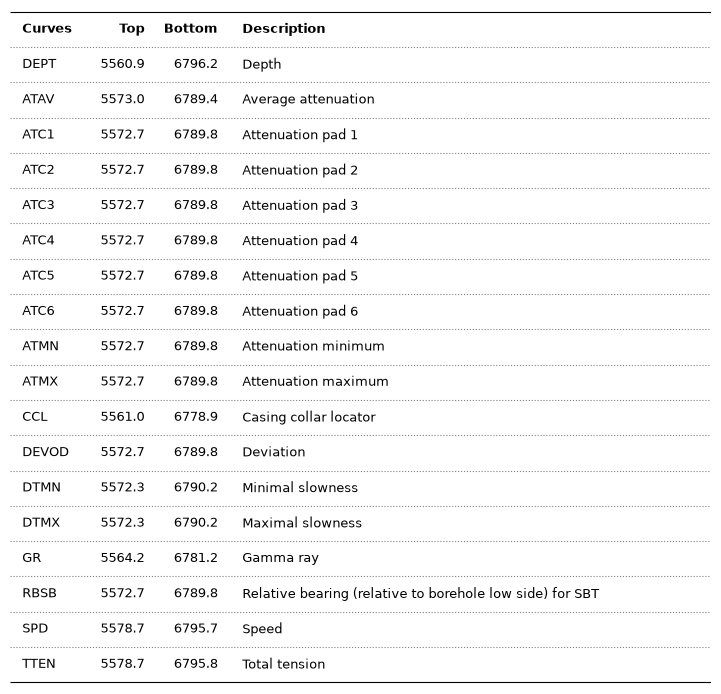

In [7]:
fig = view.plot_table()

## 3. Data coverage

`plot_coverage()` draws one bar per curve from its first to its last value. On the default *events* axis, every depth where a curve starts or stops (and every top) gets its own evenly spaced row, so offsets of a few metres between tools stay readable. The staggered starts and ends here are the tool offsets along the tool string: tension and speed are measured at the cable head, the bond tool sits lower.

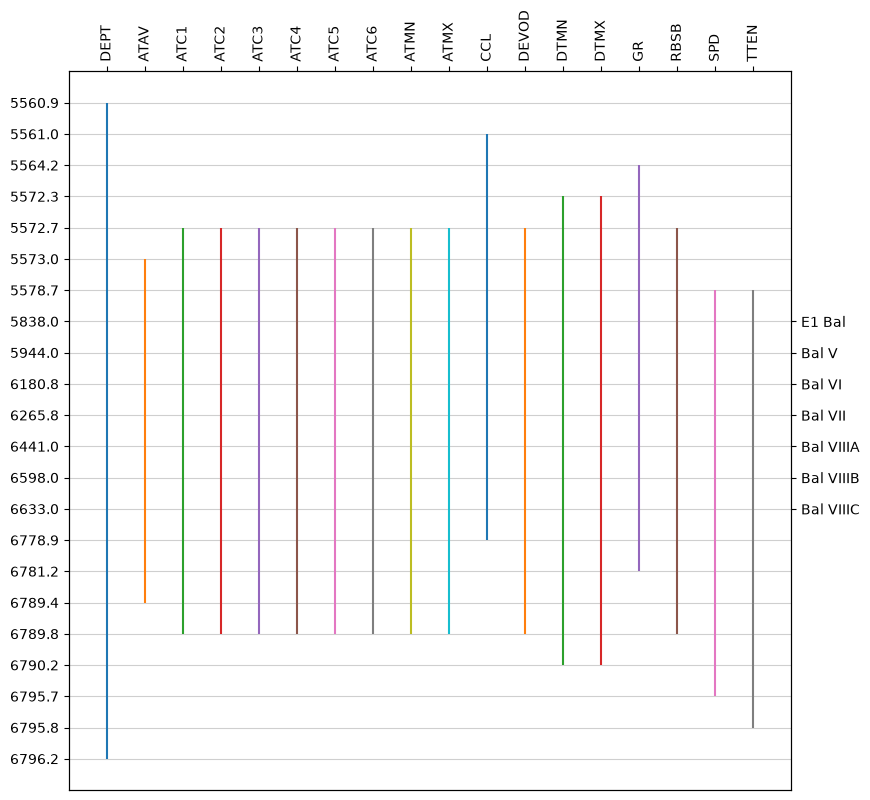

In [8]:
fig = view.plot_coverage()

With `scale="depth"` the same bars are drawn on a true depth axis.

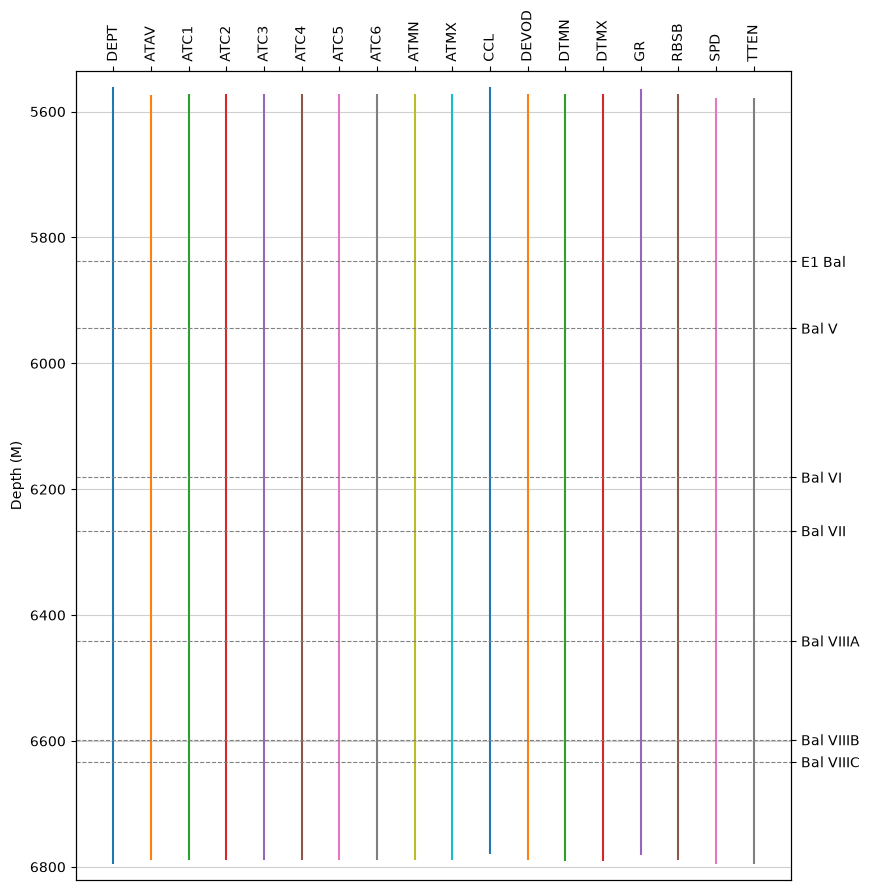

In [9]:
fig = view.plot_coverage(scale="depth")

`intervals()` lists the continuous runs of data per curve, and `gaps()` the missing intervals inside each curve. This file has no internal gaps, so `gaps()` is empty. Use `min_gap=` to ignore gaps up to a given thickness.

In [10]:
view.intervals(["CCL", "GR", "ATAV", "TTEN"])

,curve,top,bottom,thickness
0,CCL,5560.9998,6778.9044,1217.9046
1,GR,5564.2002,6781.1904,1216.9902
2,ATAV,5573.0394,6789.4200,1216.3806
3,TTEN,5578.6782,6795.8208,1217.1426


In [11]:
view.gaps()

,curve,top,bottom,thickness


## 4. Quality control

`validate()` checks the file as a whole: required header items, well identification, depth order and sampling, header STRT/STOP/STEP against the data, duplicate mnemonics, missing units, undeclared null values (such as -999 in a file declaring -999.25), empty curves and tops outside the logged interval.

In [12]:
view.validate()

,check,status,detail
0,required ~Well items,pass,"STRT, STOP, STEP, NULL"
1,well identification,warn,empty: UWI/API
2,depth unit,pass,M
3,depth values,pass,0 missing
4,depth order,pass,increasing
5,regular sampling,pass,step 0.0762 M
6,header STEP,pass,"header 0.0762, data 0.0762"
7,header STRT,pass,"header 5560.92, data 5560.92"
8,header STOP,pass,"header 6796.2, data 6796.2"
9,unique mnemonics,pass,18 curves


The file is clean apart from the missing unique well identifier (UWI/API).

`quality()` checks each curve against the physical limits of its family and looks for single-sample spikes and flat lines. Spike and flat-line checks are skipped for curves that are spiky or wrap around by design: the casing collar locator and bearings.

In [13]:
view.quality()

,family,unit,samples,missing,limits,below_min,above_max,spikes,longest_flat,flags
curve,,,,,,,,,,
ATAV,attenuation,DB/F,15964,0.0,"[0, 50]",0,0,0,0.0762,ok
ATC1,attenuation,DB/F,15974,0.0,"[0, 50]",22,0,0,0.1524,22 below 0
ATC2,attenuation,DB/F,15974,0.0,"[0, 50]",27,0,0,0.3810,27 below 0
ATC3,attenuation,DB/F,15974,0.0,"[0, 50]",8,0,0,0.3810,8 below 0
ATC4,attenuation,DB/F,15974,0.0,"[0, 50]",21,0,0,0.8382,21 below 0
ATC5,attenuation,DB/F,15974,0.0,"[0, 50]",10,0,0,1.9812,10 below 0; constant over 1.98 M
ATC6,attenuation,DB/F,15974,0.0,"[0, 50]",3,0,0,0.7620,3 below 0
ATMN,attenuation,DB/F,15974,0.0,"[0, 50]",90,0,0,1.9812,90 below 0; constant over 1.98 M
ATMX,attenuation,DB/F,15974,0.0,"[0, 50]",0,0,0,0.3810,ok


What the flags mean for this run:

- **Negative attenuation** on six of the pads and on the minimum (ATMN). Attenuation cannot be below zero, so these samples are processing artefacts and should be excluded before computing a bond index.
- **Spikes on DTMN and DTMX**: single-sample jumps in the picked slowness. Isolated jumps usually mean cycle skipping, but the close-up below shows many of them where the attenuation also changes quickly, so check them against the waveforms before discarding them. One DTMN value (38.8 us/ft) is faster than any formation or steel.
- **Constant stretches** of about 2 m on ATC5, ATMN and the deviation are worth a look but are short.

The underlying data are available through `view.log` (a `pphys.WellLog`), e.g. to find where ATMN is negative:

In [14]:
atmn = view.log.df()["ATMN"]
negative = atmn[atmn < 0]
print(f"{negative.size} samples between {negative.index.min():.1f} and {negative.index.max():.1f} m")

90 samples between 5650.4 and 6462.4 m


A close look at the slowness spikes, with `plot_logs()` on a short depth window:

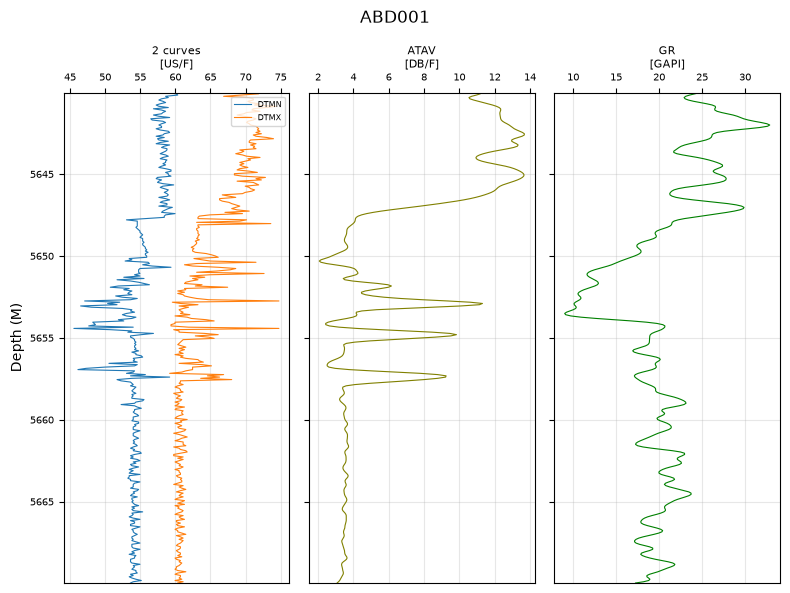

In [15]:
fig = view.plot_logs([["DTMN", "DTMX"], "ATAV", "GR"], top=5640, base=5670, figsize=(8, 6))

## 5. Statistics and distributions

`statistics()` gives count, mean, standard deviation, minimum, P10, P50, P90 and maximum per curve. Statistics of angles such as RBSB (a bearing that wraps from 360 to 0 degrees) are not meaningful.

In [16]:
view.statistics().round(2)

,unit,count,mean,std,min,p10,p50,p90,max
curve,,,,,,,,,
ATAV,DB/F,15964,6.09,3.03,2.07,3.45,4.27,10.71,15.67
ATC1,DB/F,15974,5.70,2.71,-3.41,3.15,4.47,9.64,17.61
ATC2,DB/F,15974,5.39,3.00,-3.89,2.65,3.87,9.77,20.81
ATC3,DB/F,15974,6.74,3.64,-1.26,3.45,4.78,12.39,21.84
ATC4,DB/F,15974,6.36,3.84,-3.11,3.12,4.07,12.54,18.35
ATC5,DB/F,15974,5.89,2.90,-0.99,3.30,4.39,10.43,18.05
ATC6,DB/F,15974,6.46,3.00,-0.66,3.23,5.61,10.79,18.93
ATMN,DB/F,15974,4.72,2.73,-3.89,2.38,3.33,9.03,13.39
ATMX,DB/F,15974,7.62,3.56,3.15,4.19,5.80,12.95,21.84


`plot_histograms()` shows the distributions with P10 and P90 dotted and P50 dashed. All attenuation curves are bimodal: two populations of bond response.

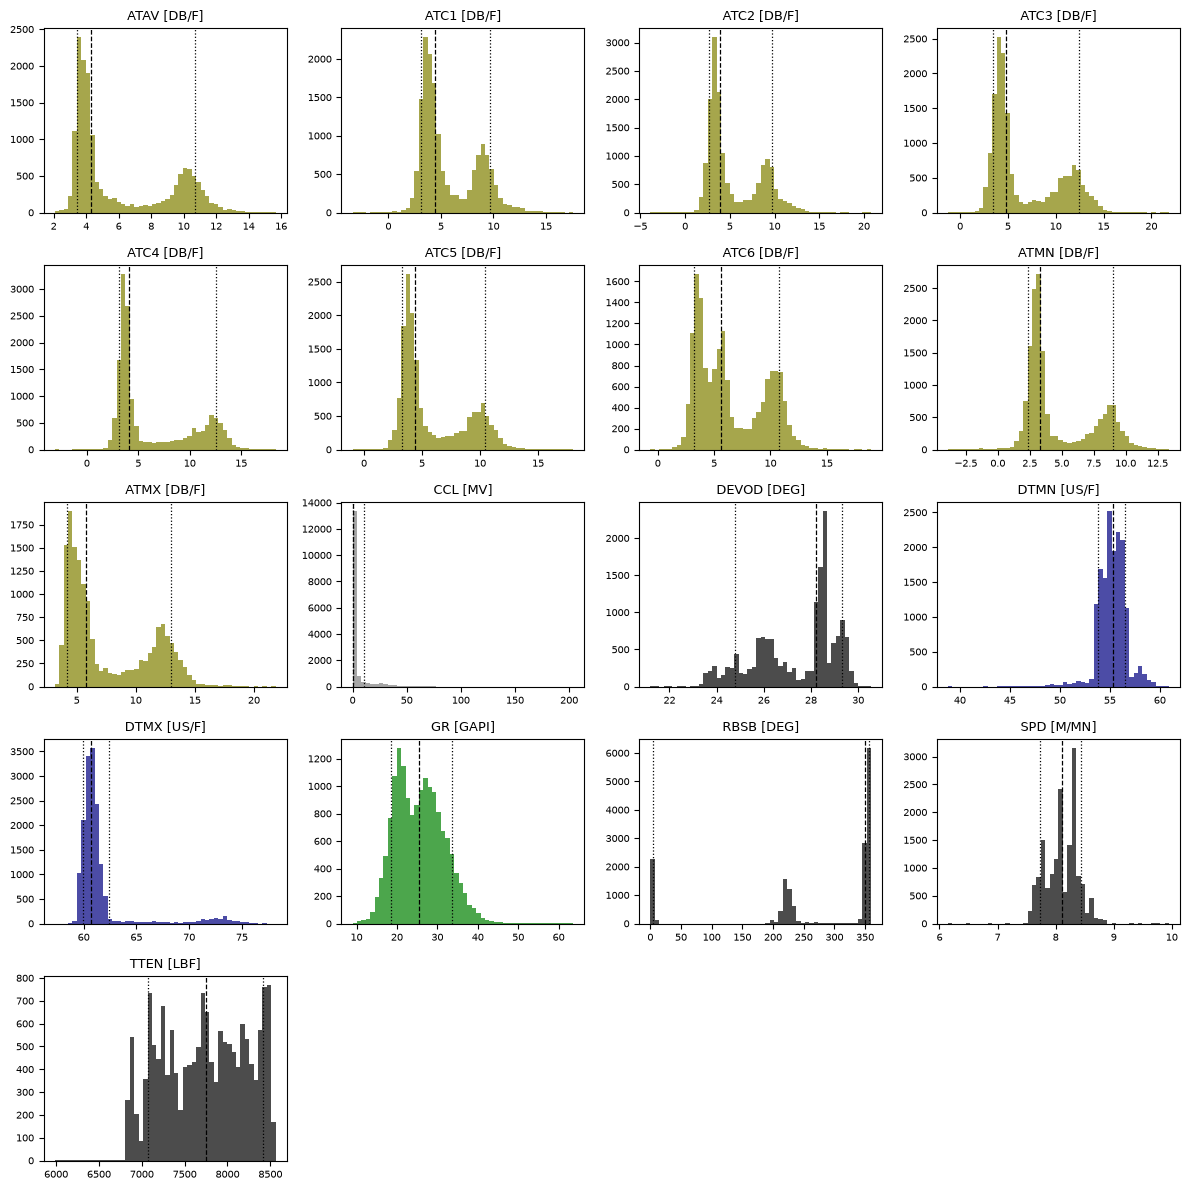

In [17]:
fig = view.plot_histograms()

## 6. Formation zones

`zones()` turns the tops into intervals, and `zone_statistics()` summarizes curves per zone (mean by default; any pandas aggregation works).

In [18]:
view.zones()

,formation,top,base,thickness
0,E1 Bal,5838.0,5944.0000,106.0000
1,Bal V,5944.0,6180.8000,236.8000
2,Bal VI,6180.8,6265.8000,85.0000
3,Bal VII,6265.8,6441.0000,175.2000
4,Bal VIIIA,6441.0,6598.0000,157.0000
5,Bal VIIIB,6598.0,6633.0000,35.0000
6,Bal VIIIC,6633.0,6796.2018,163.2018


In [19]:
view.zone_statistics(["GR", "ATMN", "ATAV", "ATMX", "DTMN", "DEVOD"]).round(2)

,GR,ATMN,ATAV,ATMX,DTMN,DEVOD
formation,,,,,,
E1 Bal,19.84,2.75,3.86,4.89,54.36,28.54
Bal V,28.40,3.08,4.13,5.36,54.85,25.13
Bal VI,27.91,3.06,4.40,5.97,55.29,25.93
Bal VII,26.66,3.19,4.52,6.08,55.26,26.28
Bal VIIIA,27.97,6.71,8.69,10.82,55.53,27.87
Bal VIIIB,27.82,8.52,10.41,12.68,55.36,29.05
Bal VIIIC,27.86,8.72,10.42,12.43,55.98,29.41


Average attenuation (ATAV) rises from about 4 dB/ft in E1 Bal to Bal VII to 9-10 dB/ft in Bal VIIIA to Bal VIIIC. In an SBT log higher attenuation means more energy lost to the cement, i.e. better bond; the calibration in the `~Other` section converts attenuation to a bond index once the casing string across the interval is known. The median shows the same step:

In [20]:
view.zone_statistics("ATAV", stat="median").round(2)

,ATAV
formation,
E1 Bal,3.69
Bal V,3.96
Bal VI,4.15
Bal VII,4.28
Bal VIIIA,9.45
Bal VIIIB,10.30
Bal VIIIC,10.35


## 7. Log display

`plot_logs()` draws one track per curve or per group of curves (a nested list). Resistivity-type curves get a logarithmic axis automatically, and the tops are drawn across all tracks.

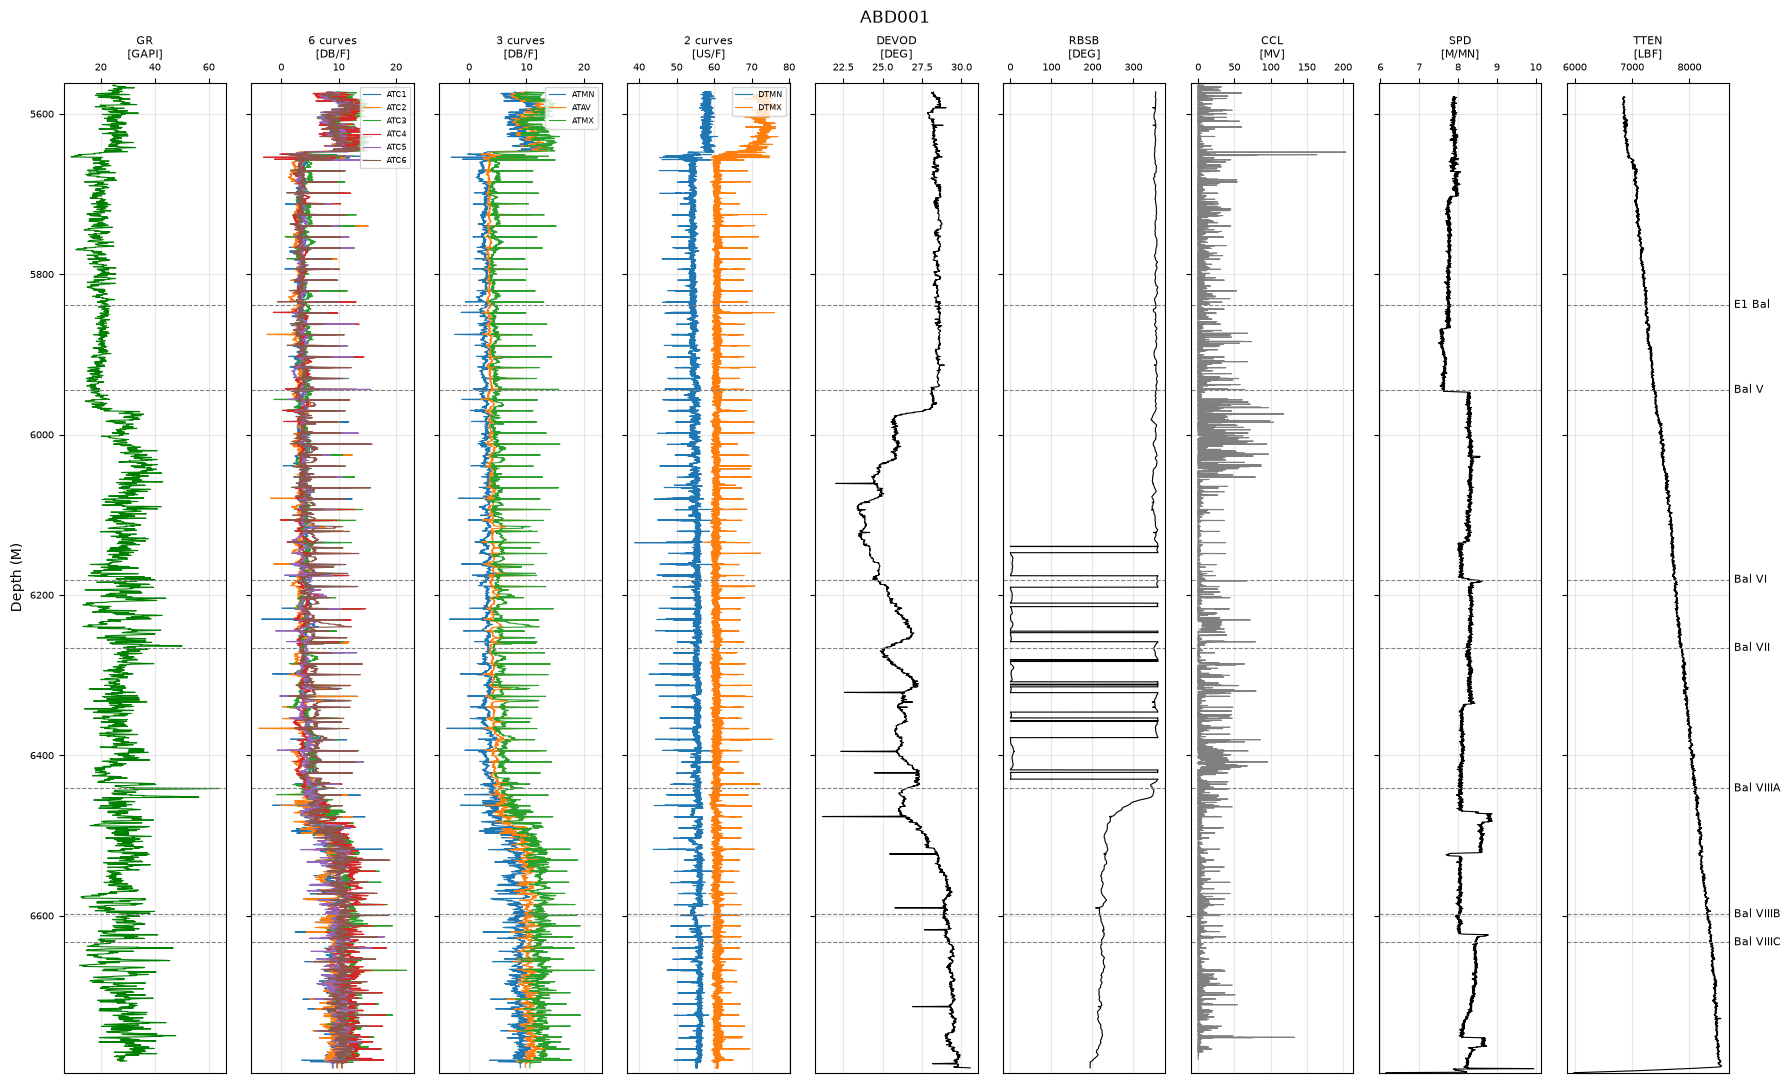

In [21]:
fig = view.plot_logs(
    [
        "GR",
        ["ATC1", "ATC2", "ATC3", "ATC4", "ATC5", "ATC6"],
        ["ATMN", "ATAV", "ATMX"],
        ["DTMN", "DTMX"],
        "DEVOD",
        "RBSB",
        "CCL",
        "SPD",
        "TTEN",
    ],
    figsize=(18, 11),
)

`window(top, base)` returns a new `LasView` on part of the log, so every table and plot works on that interval. Here, the transition into Bal VIIIA:

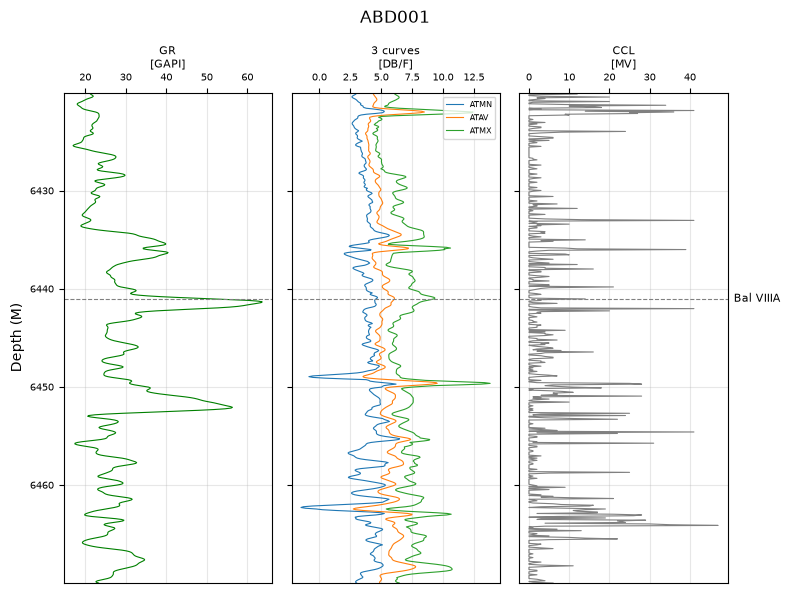

In [22]:
transition = view.window(6420, 6470)
fig = transition.plot_logs(
    ["GR", ["ATMN", "ATAV", "ATMX"], "CCL"], figsize=(8, 6)
)

In [23]:
transition.zone_statistics(["GR", "ATAV"]).round(2)

,GR,ATAV
formation,,
E1 Bal,NaN,NaN
Bal V,NaN,NaN
Bal VI,NaN,NaN
Bal VII,25.42,4.83
Bal VIIIA,29.74,5.65
Bal VIIIB,NaN,NaN
Bal VIIIC,NaN,NaN


## 8. Crossplots and correlation

`plot_crossplot(x, y, color=...)` plots one curve against another, optionally coloured by a third; the depth curve can be used too.

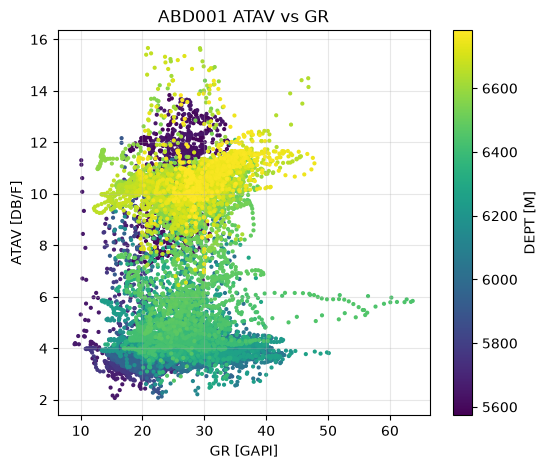

In [24]:
fig = view.plot_crossplot("GR", "ATAV", color="DEPT")

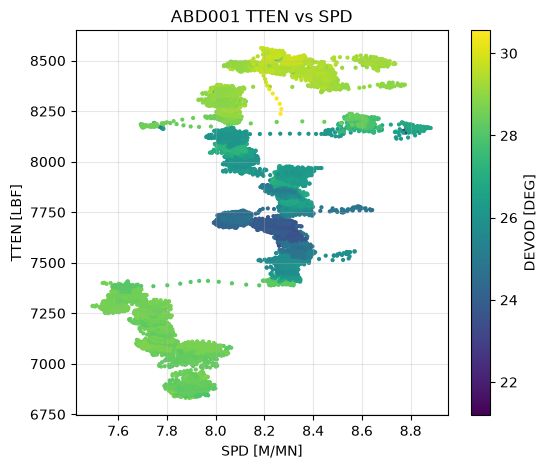

In [25]:
fig = view.plot_crossplot("SPD", "TTEN", color="DEVOD")

`plot_correlation()` shows the correlation matrix. The attenuation curves correlate strongly with each other, the collar locator with nothing, and tension with logging speed. Use `method="spearman"` for curves related non-linearly.

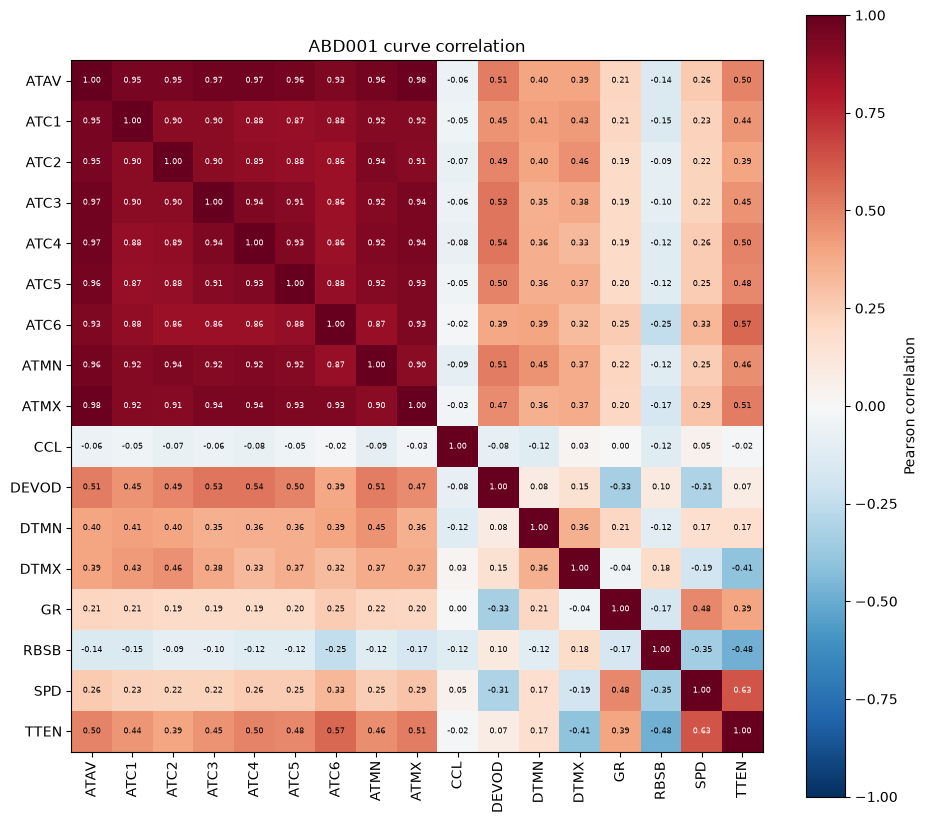

In [26]:
fig = view.plot_correlation()

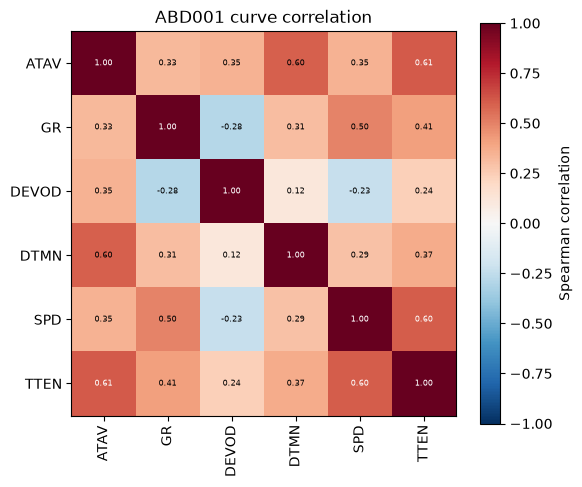

In [27]:
fig = view.plot_correlation(["ATAV", "GR", "DEVOD", "DTMN", "SPD", "TTEN"], method="spearman")

## 9. Report

`save_report(path)` writes all of the above to a multi-page PDF: summary, file checks, inventory, coverage, statistics, curve quality, zones, logs, histograms and correlation.

In [28]:
report = view.save_report(Path(tempfile.gettempdir()) / "ABD001_lasview.pdf")
print(f"{report.name}: {report.stat().st_size / 1e6:.1f} MB")

ABD001_lasview.pdf: 1.0 MB
